# 09 — Build your own plugin

AerEO plugins are **plain Python functions** — no base classes, no inheritance, no framework API to learn. You register them under the `aereo.plugins` entry-point group and AerEO discovers them automatically.

In this notebook we build `to_db`, a tiny processor that converts Sentinel-1 linear backscatter to decibels, package it as a real installable plugin, and run it in an extraction job — reusing the Sentinel-1 setup from notebook 07.

In [1]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz,pc]"

In [2]:
# Install the demo plugin package that ships in the aereo repo.
# (When running inside the repo: pip install -e examples/plugins/aereo_demo_plugin)
!pip install -q "git+https://github.com/frandorr/aereo.git#subdirectory=examples/plugins/aereo_demo_plugin"

In [3]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files (job_sentinel1-db.yaml inherits from job_sentinel1.yaml)
for name in ["job_sentinel1.yaml", "job_sentinel1-db.yaml"]:
    urllib.request.urlretrieve(
        f"{GITHUB_RAW}/examples/config/{name}",
        f"config/{name}",
    )

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## The plugin: one function, one entry point

This is the entire processor (`examples/plugins/aereo_demo_plugin/src/aereo_demo_plugin/processors.py`):

```python
import numpy as np
import xarray as xr
from pydantic import ConfigDict, validate_call


@validate_call(config=ConfigDict(arbitrary_types_allowed=True))
def to_db(ds: xr.Dataset, clip_min: float = 1e-6) -> xr.Dataset:
    """Convert linear backscatter (e.g. Sentinel-1 vv/vh) to decibels."""
    return 10.0 * np.log10(ds.clip(min=clip_min))
```

And its registration in the package's `pyproject.toml`. The `process_` prefix tells AerEO this is a **processor** stage (`search_`, `read_`, `reproject_`, `write_`, `task_builder_` work the same way):

```toml
[project.entry-points."aereo.plugins"]
process_to_db = "aereo_demo_plugin.processors:to_db"
```

The contract is just the signature: a processor takes an `xr.Dataset` and returns one. It can be used as `preprocess` (before reprojection) or `postprocess` (after).

## Discovery: the plugin is now in the registry

Once the package is installed, AerEO finds it via entry points — no imports, no wiring:

In [4]:
from aereo.registry import AereoRegistry

registry = AereoRegistry()
print("process_to_db registered:", "process_to_db" in registry.list_all_params())
print("parameters:", registry.get_plugin_params("process_to_db"))

2026-07-27 11:07:43 [info     ] Discovering aereo plugins...


2026-07-27 11:07:44 [debug    ] Loaded processor: process_composite


2026-07-27 11:07:44 [debug    ] Loaded processor: process_ndvi


2026-07-27 11:07:44 [debug    ] Loaded processor: process_ndwi


2026-07-27 11:07:44 [debug    ] Loaded processor: process_normalize


...

2026-07-27 11:07:44 [debug    ] Loaded writer: write_geotiff


2026-07-27 11:07:44 [debug    ] Loaded processor: process_to_db


2026-07-27 11:07:44 [debug    ] Loaded reader: read_earthlens


2026-07-27 11:07:44 [debug    ] Loaded searcher: search_earthlens


process_to_db registered: True
parameters: {'required': [], 'optional': [{'name': 'clip_min', 'default': 1e-06, 'type': "<class 'float'>", 'description': ''}]}


## Use it from config

`config/job_sentinel1-db.yaml` inherits the Sentinel-1 job from notebook 07 and adds the plugin as `postprocess` — Hydra instantiates it by dotted path, exactly like the built-in stages:

```yaml
defaults:
  - job_sentinel1
  - _self_

name: sentinel1_db
output_uri: /tmp/aereo_extraction_s1_db

postprocess:
  - _target_: aereo_demo_plugin.processors.to_db
    _partial_: true
```

In [5]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel1-db",
)

In [6]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-27 11:07:44 [info     ] search_called                  provider=search_stac


2026-07-27 11:07:47 [info     ] build_tasks_start              assets=4 builder=build_grouped_tasks


/home/fran/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


2

In [7]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())

In [8]:
# Extract! Each task runs read -> reproject -> postprocess (our to_db) -> write.
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

Extracting...
2026-07-27 11:07:47 [info     ] execute_start                  executor=LocalExecutor task_count=2


✓ Extracted 20 artifacts


## Plot the extracted patches

Same scene as notebook 07, but the GeoTIFFs now store **decibels** — the plugin ran inside the pipeline, after reprojection to the Major TOM grid.

(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


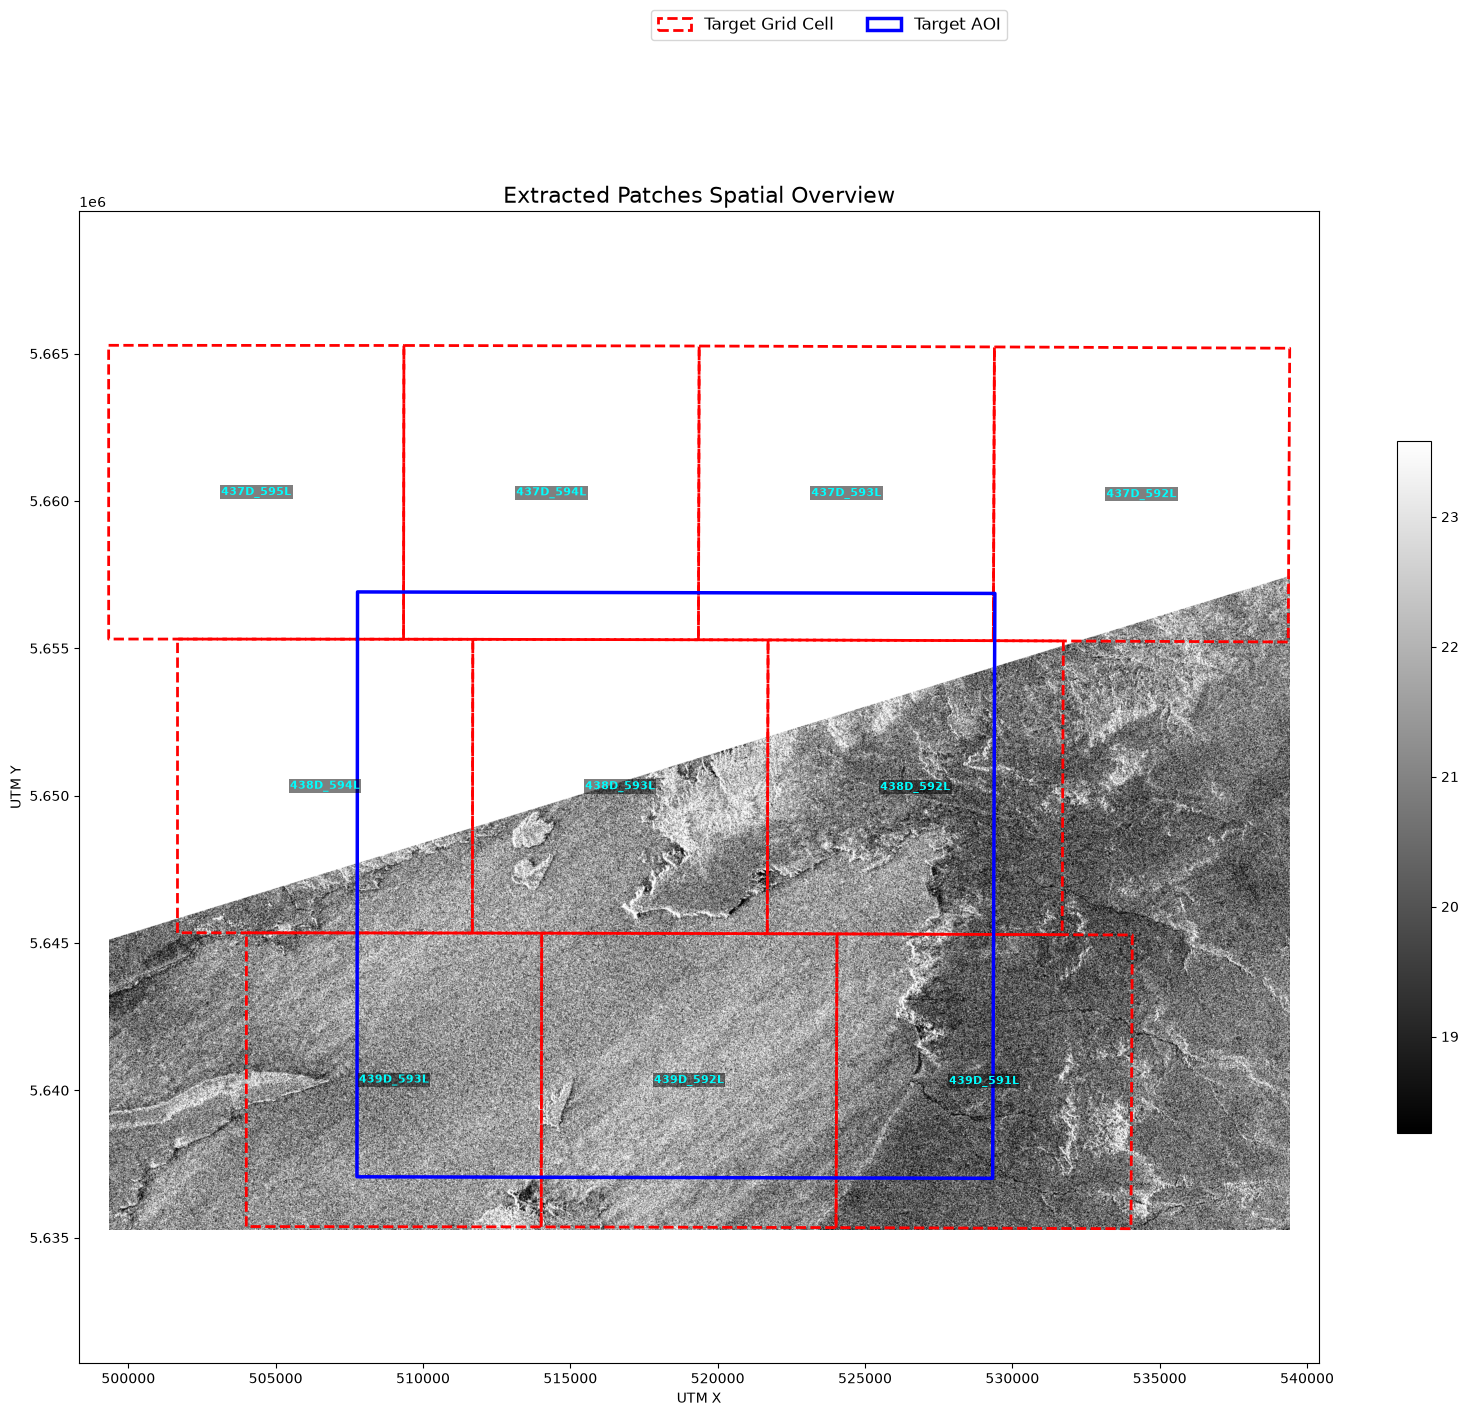

In [9]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="gray",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)

## Alternative: skip packaging, pass the function directly

Entry points make a plugin discoverable and shareable. But for quick experiments you don't even need a package — any function can be passed straight to the job:

```python
from aereo.pipeline import ExtractionJob
from aereo_demo_plugin.processors import to_db

job = ExtractionJob(
    name="s1_db_inline",
    grid_dist=10_000,
    output_uri="/tmp/aereo_s1_db_inline",
    search=search_stac,
    read=read_odc_stac,
    postprocess=[to_db],   # <- just a function
    write=write_geotiff,
    target_aoi=aoi,
)
```

Package it when you want to share it; keep it inline while you iterate. See [Build a Plugin](https://frandorr.github.io/aereo/plugins/build-a-plugin/) for the full stage-by-stage reference.